In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("C:/Users/15177459/Desktop/bopha/Personality and selection of companies (DSSA)_April 20, 2026_04.35.csv")
print(len(df))

310


In [167]:
print(df.columns)


Index(['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
       'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
       'RecipientLastName',
       ...
       'Comp A Exploit_Exploit', 'Comp A Exploit_Ins', 'Comp A Exploit_Soci',
       'Comp A Exploit_Obs', 'Comp A Exploit_Duty', 'Comp A Exploit_Explor',
       'Debriefing', 'SONA_debriefing', 'id', 'Source'],
      dtype='str', length=234)


In [168]:
new_columns = {
    'Comp A Exploit_Exploit': "Comp_B_Explor_Exploit",
    'Comp A Exploit_Ins': "Comp_B_Explor_Ins",
    'Comp A Exploit_Soci': "Comp_B_Explor_Soci",
    'Comp A Exploit_Obs': "Comp_B_Explor_Obs",
    'Comp A Exploit_Duty': "Comp_B_Explor_Duty",
    'Comp A Exploit_Explor': "Comp_B_Explor_Explor"
}

df = df.rename(columns=new_columns)

print(df.columns.tolist())
print(df.head())


['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'RecipientFirstName', 'RecipientEmail', 'ExternalReference', 'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 'UserLanguage', 'Consent_form', 'Recruitment', 'SONA_ID', 'Gender', 'Gender_3_TEXT', 'Age', 'Student', 'Year_of_study', 'Year_of_study_6_TEXT', 'Type_study', 'Type_study_4_TEXT', 'Education', 'Work_exp', 'employment', 'Weekly_hrs', 'Employed_Industry', 'Employed_Industry_21_TEXT', 'employed_Occupation', 'employed_Occupation_24_TEXT', 'Desired_industry', 'Desired_industry_21_TEXT', 'Desired_occupation', 'Desired_occupation_24_TEXT', 'Employees_nr', 'Twolvl_company_1', 'Threelvl_company_1', 'Fivelvl_company_1', 'Sevenlvl_company_1', 'Unemployed_industry', 'Unemployed_industry_21_TEXT', 'Unemployed_occupatio', 'Unemployed_occupatio_24_TEXT', 'Oaesa1', 'Corga3', 'Aforg1', 'Xsses1', 'Efear1', 'Hsinc4', 'Oinqu1', 'Cdili2', 

In [169]:
# Cleaning Data

bad_respondents = [
    "R_87BZLd8akobbh8U",
    "R_2bNJxCYf4hmuet0",
    "R_8dBhGl7XMl4jjIl"
]

df = df[
    (df["Finished"] != "0") &
    (~df["ResponseId"].isin(bad_respondents))
].copy()

print(len(df))
print("Unfinished rows:", (df["Finished"] == 0).sum())
print("Bad respondent rows:", df["ResponseId"].isin(bad_respondents).sum())

191
Unfinished rows: 0
Bad respondent rows: 0


In [170]:
columns_to_reverse = ["Oaesa1", "Oinqu8", "Ocrea8", "Ounco2", "Ounco8"]

for i in columns_to_reverse:
    print(df[i].head)

<bound method NDFrame.head of 0      For every statement please indicate to what ex...
1                                 {"ImportId":"QID72_1"}
2                                                      3
3                                                      2
4                                                      4
                             ...                        
292                                                    1
294                                                    4
296                                                    5
300                                                    1
308                                                    2
Name: Oaesa1, Length: 191, dtype: str>
<bound method NDFrame.head of 0      For every statement please indicate to what ex...
1                                 {"ImportId":"QID75_5"}
2                                                      2
3                                                      4
4                                             

In [171]:
# Recode Opennes columns

reverse_map = {
    "1":5,
    "2":4,
    "3":3,
    "4":2,
    "5":1
}

columns_to_reverse = ["Oaesa1", "Oinqu8", "Ocrea8", "Ounco2", "Ounco8"]

for i in columns_to_reverse:
    df[i] = df[i].map(reverse_map)
    print(df[i].head)

<bound method NDFrame.head of 0      NaN
1      NaN
2      3.0
3      4.0
4      2.0
      ... 
292    5.0
294    2.0
296    1.0
300    5.0
308    4.0
Name: Oaesa1, Length: 191, dtype: float64>
<bound method NDFrame.head of 0      NaN
1      NaN
2      4.0
3      2.0
4      4.0
      ... 
292    4.0
294    2.0
296    5.0
300    2.0
308    2.0
Name: Oinqu8, Length: 191, dtype: float64>
<bound method NDFrame.head of 0      NaN
1      NaN
2      2.0
3      3.0
4      2.0
      ... 
292    5.0
294    4.0
296    4.0
300    5.0
308    1.0
Name: Ocrea8, Length: 191, dtype: float64>
<bound method NDFrame.head of 0      NaN
1      NaN
2      5.0
3      4.0
4      4.0
      ... 
292    5.0
294    3.0
296    4.0
300    5.0
308    4.0
Name: Ounco2, Length: 191, dtype: float64>
<bound method NDFrame.head of 0      NaN
1      NaN
2      2.0
3      2.0
4      4.0
      ... 
292    5.0
294    2.0
296    1.0
300    5.0
308    3.0
Name: Ounco8, Length: 191, dtype: float64>


In [172]:
# Openness Average

openness_items = ['Oaesa1', 'Oinqu1', 'Ocrea6', 'Oaesa4', 'Oinqu8', 'Ocrea7', 'Ounco2', 'Ounco5', 'Ocrea8', 'Ounco8']

dic_scores = {}

for i in openness_items:
    df[i] = pd.to_numeric(df[i], errors="coerce")
    dic_scores[i] = df[i].mean()

print("Average scores by item:")
print("-" * 30)

for item, score in dic_scores.items():
    print(f"{item}: {score:.2f}")

avg = 0
for keys, values in dic_scores.items():
    avg += values

print(f"Composite Average = {avg/(len(openness_items)): .2f}")

Average scores by item:
------------------------------
Oaesa1: 3.43
Oinqu1: 3.26
Ocrea6: 3.59
Oaesa4: 3.33
Oinqu8: 2.98
Ocrea7: 3.52
Ounco2: 3.64
Ounco5: 3.47
Ocrea8: 3.22
Ounco8: 3.52
Composite Average =  3.39


In [173]:
# Z score Exploration Composite Score
# Explor_sel_rating_2 was already in the correct direction so it does not need to be recoded

df["Explor_selection"] = df["Explor_selection"].map({
    "0":1,
    "1":0
})

df["Explor_sel_rating"] = df["Explor_sel_rating"].map({
    "6":1,
    "5":2,
    "4":3,
    "3":4,
    "2":5,
    "1":6
})

df["Explor_selection_z"] = (df["Explor_selection"] - df["Explor_selection"].mean())/df["Explor_selection"].std()
df["Explor_sel_rating_z"] = (df["Explor_sel_rating"] - df["Explor_sel_rating"].mean())/df["Explor_sel_rating"].std()

df["Explor_sel_rating2_1"] = pd.to_numeric(df["Explor_sel_rating2_1"], errors="coerce")
df["Explor_sel_rating2_z"] = (df["Explor_sel_rating2_1"] - df["Explor_sel_rating2_1"].mean())/df["Explor_sel_rating2_1"].std()

df["Exploration_Composite_Score"] = df[["Explor_selection_z", "Explor_sel_rating_z", "Explor_sel_rating2_z"]].mean(axis=1)

print("\nPreview")
print(
    df.iloc[:, 2:][
        ["Explor_selection", "Explor_sel_rating", "Explor_sel_rating2_1", "Exploration_Composite_Score"]
    ].head()
)

df["Openness_Average"] = df[openness_items].mean(axis=1)
print(
    df[openness_items + ["Openness_Average"]].head()
)



Preview
   Explor_selection  Explor_sel_rating  Explor_sel_rating2_1  \
0               NaN                NaN                   NaN   
1               NaN                NaN                   NaN   
2               1.0                6.0                  12.0   
3               0.0                2.0                  74.0   
4               1.0                5.0                  19.0   

   Exploration_Composite_Score  
0                          NaN  
1                          NaN  
2                     0.318400  
3                    -0.613871  
4                     0.160464  
   Oaesa1  Oinqu1  Ocrea6  Oaesa4  Oinqu8  Ocrea7  Ounco2  Ounco5  Ocrea8  \
0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
1     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2     3.0     3.0     4.0     3.0     4.0     2.0     5.0     4.0     2.0   
3     4.0     2.0     4.0     5.0     2.0     3.0     4.0     3.0     3.0   
4     2.0     4.0     4

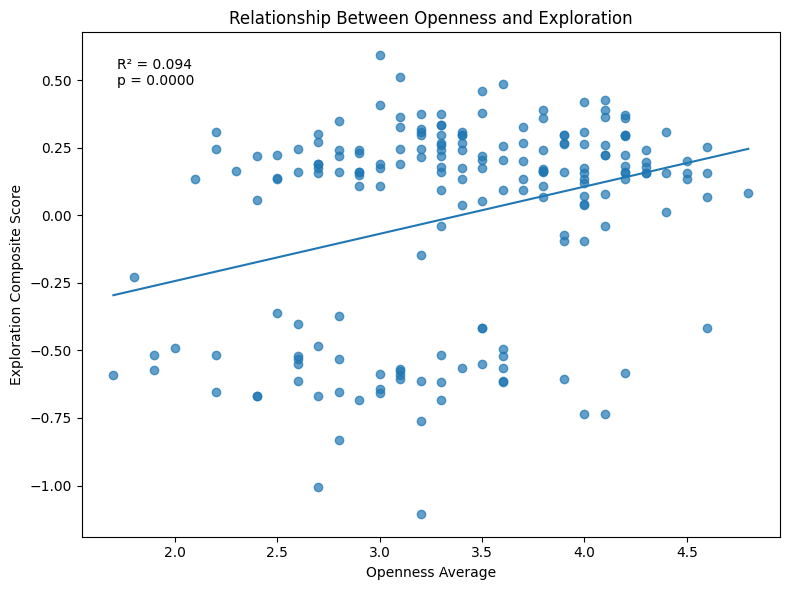

In [176]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Make sure both columns are numeric
df["Openness_Average"] = pd.to_numeric(df["Openness_Average"], errors="coerce")
df["Exploration_Composite_Score"] = pd.to_numeric(df["Exploration_Composite_Score"], errors="coerce")

# Drop missing values
reg_df = df[["Openness_Average", "Exploration_Composite_Score"]].dropna()

# Regression
X = sm.add_constant(reg_df["Openness_Average"])
y = reg_df["Exploration_Composite_Score"]

model = sm.OLS(y, X).fit()

# Predicted regression line
x_vals = np.linspace(reg_df["Openness_Average"].min(), reg_df["Openness_Average"].max(), 100)
X_pred = sm.add_constant(x_vals)
y_pred = model.predict(X_pred)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    reg_df["Openness_Average"],
    reg_df["Exploration_Composite_Score"],
    alpha=0.7
)

plt.plot(x_vals, y_pred)

plt.title("Relationship Between Openness and Exploration")
plt.xlabel("Openness Average")
plt.ylabel("Exploration Composite Score")

plt.text(
    0.05,
    0.95,
    f"R² = {model.rsquared:.3f}\np = {model.pvalues['Openness_Average']:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()